# Task 2 - Generative AI: Domain-Specific Fine-Tuning Pipeline

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage/blob/main/task2_genai/task2_finetuning.ipynb)

CDAZZDEV Senior Machine Learning Engineer Technical Assessment - Gimsara Elgiriyage

## 0. Setup

GPU check, dependency installation, and secrets loaded from Colab Secrets. No credentials are hardcoded.

In [1]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Colab clones the public repo and installs Task 2 requirements. Locally we only find the repo root.
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/GimsaraK/CDAZZDEV-MLE-Gimsara_Elgiriyage.git"
REPO_NAME = "CDAZZDEV-MLE-Gimsara_Elgiriyage"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    repo_root = Path("/content") / REPO_NAME
    if not repo_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(repo_root)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(repo_root / "task2_genai" / "requirements.txt")],
        check=True,
    )
    # Colab ships torchao 0.10. Recent peft refuses any torchao older than 0.16 when it loads a
    # LoRA adapter onto an unquantized model, which the section 8 merge does. Nothing here uses torchao.
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"], check=False)
else:
    here = Path.cwd().resolve()
    repo_root = here if (here / "task2_genai").exists() else here.parent
# Both branches import task2_genai from the repo root.
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Running in Colab:", IN_COLAB)
print("Repository root :", repo_root)


Running in Colab: True
Repository root : /content/CDAZZDEV-MLE-Gimsara_Elgiriyage


# Part 2A - Use Case Definition and Dataset Engineering

## 1. Problem Statement

Closed-book compliance assistant for the fictional company Northwind Components. The model does not receive the policy manual in the user turn. It has to apply the rules it was trained on.

| | |
|---|---|
| Input | One employee scenario: who did what, and what they want |
| Output | JSON with `policy_ids`, `required_action`, and `rationale` |
| Correct | Every id is in the manual, or `["NONE"]` when no rule applies, and the action is the one that clause states |
| Incorrect | An unknown id, the wrong clause, an action the clause does not allow, or a rule that was invented |

A generic chatbot answer, or a paragraph that does not name a policy, is incorrect. The manual is fictional and is not legal advice.


In [2]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Show the closed-book contract: the user turn is a scenario, the label is JSON from the manual.
import json
from task2_genai.src.manual import load_manual
from task2_genai.src import config

manual = load_manual()
print("Company:", manual["company"])
print("Input : one employee scenario. The policy manual is not included in the user turn.")
print("Output: JSON with policy_ids, required_action, and rationale.")
print('Correct  : every id is in the manual, or ["NONE"] when nothing applies, and the action matches that clause.')
print("Incorrect: an unknown id, the wrong clause, an action the clause does not allow, or an invented rule.")
print("Policies:")
for policy in manual["policies"]:
    print(f"  {policy['id']}  {policy['topic']}")
print("Teacher:", config.TEACHER_MODEL_GROQ)
print("Student chat template:", config.STUDENT_MODEL)


Company: Northwind Components
Input : one employee scenario. The policy manual is not included in the user turn.
Output: JSON with policy_ids, required_action, and rationale.
Correct  : every id is in the manual, or ["NONE"] when nothing applies, and the action matches that clause.
Incorrect: an unknown id, the wrong clause, an action the clause does not allow, or an invented rule.
Policies:
  NW-LEAVE  leave
  NW-EXPENSE  expenses
  NW-GIFT  gifts
  NW-PRIVACY  privacy
  NW-SAFETY  safety
  NW-REMOTE  remote
  NW-REPORT  reporting
  NW-ACCEPT  acceptable_use
Teacher: openai/gpt-oss-120b
Student chat template: Qwen/Qwen2.5-1.5B-Instruct


## 2. Synthetic Data Generation (Teacher Model)

The teacher is Groq `openai/gpt-oss-120b`. OpenRouter is called only when Groq returns nothing that passes validation. Eight policy topics are crossed with five situation types, and each cell keeps 5 scenarios that survive the schema check and the exact / character 5-gram duplicate checks. If `accepted.jsonl` already has 200 rows, this cell loads them and does not call the teacher.

In [3]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Load the committed JSONL when it is already complete. Call the teacher only to fill a gap.
import json
from task2_genai.src import config
from task2_genai.src.client import load_api_keys
from task2_genai.src.generate import _read_jsonl, generate_dataset

keys = load_api_keys()
print("GROQ_API_KEY set:" , keys["GROQ_API_KEY"])
print("OPENROUTER_API_KEY set:", keys["OPENROUTER_API_KEY"])

accepted = _read_jsonl(config.ACCEPTED_PATH)
if len(accepted) >= config.TARGET_ACCEPTED:
    print(f"Loaded {len(accepted)} accepted rows from {config.ACCEPTED_PATH.name}. Teacher was not called.")
    generate_dataset()
else:
    print("Accepted file is short. Generating the remaining cells.")
    generate_dataset()

report = json.loads(config.GENERATION_REPORT_PATH.read_text(encoding="utf-8"))
print(json.dumps(report, indent=2))


GROQ_API_KEY set: True
OPENROUTER_API_KEY set: True
Loaded 200 accepted rows from accepted.jsonl. Teacher was not called.
{
  "returned": 200,
  "schema_rejected": 0,
  "exact_dropped": 0,
  "near_dropped": 0,
  "accepted": 200,
  "repair_calls": 2,
  "fallback_calls": 0,
  "provider_failed": 0,
  "train": 160,
  "val": 20,
  "test": 20,
  "teacher_model": "openai/gpt-oss-120b",
  "student_model": "Qwen/Qwen2.5-1.5B-Instruct"
}


## 3. Dataset Diversity Analysis

Prompt length distribution and keyword / topic frequency.

{
  "length_words": {
    "n": 200,
    "min": 40,
    "median": 64.0,
    "p90": 96.0,
    "max": 149,
    "mean": 68.0
  },
  "topic_counts": {
    "acceptable_use": 25,
    "expenses": 25,
    "gifts": 25,
    "leave": 25,
    "privacy": 25,
    "remote": 25,
    "reporting": 25,
    "safety": 25
  },
  "situation_counts": {
    "borderline": 40,
    "clear_breach": 40,
    "compliant": 40,
    "not_covered": 40,
    "two_policy": 40
  },
  "top_keywords": [
    {
      "token": "company",
      "count": 135
    },
    {
      "token": "personal",
      "count": 128
    },
    {
      "token": "laptop",
      "count": 79
    },
    {
      "token": "policy",
      "count": 73
    },
    {
      "token": "manager",
      "count": 70
    },
    {
      "token": "also",
      "count": 60
    },
    {
      "token": "software",
      "count": 56
    },
    {
      "token": "expense",
      "count": 53
    },
    {
      "token": "gift",
      "count": 52
    },
    {
      "token": "day

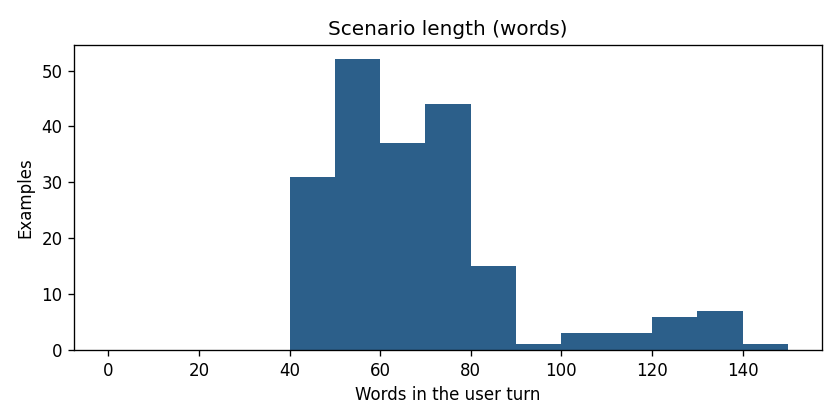

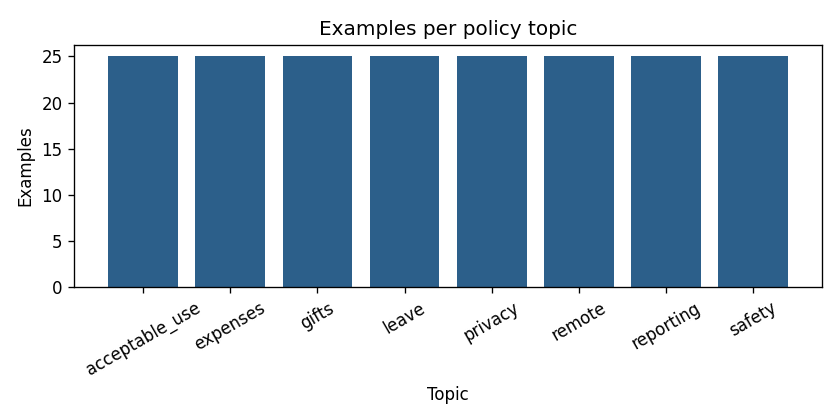

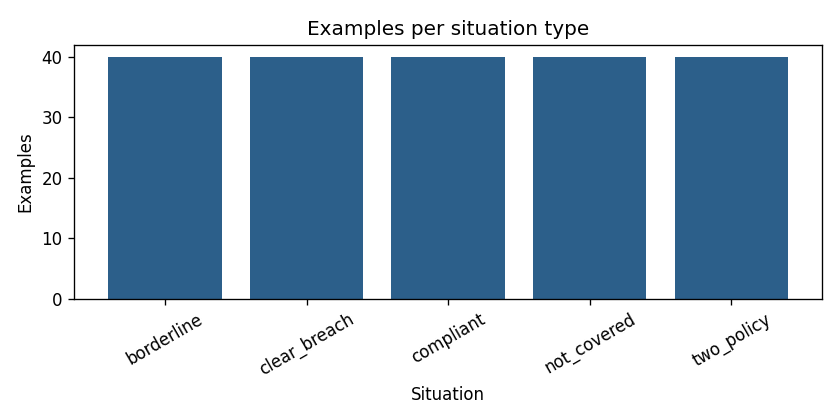

In [4]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Length histogram, topic and situation counts, and the top scenario keywords.
import json
from IPython.display import Image, display
from task2_genai.src import config
from task2_genai.src.diversity import diversity_report
from task2_genai.src.generate import _read_jsonl

rows = _read_jsonl(config.ACCEPTED_PATH)
report = diversity_report(rows)
public = {key: value for key, value in report.items() if key != "lengths"}
print(json.dumps(public, indent=2))
for name in ("prompt_length_hist.png", "topic_frequency.png", "situation_frequency.png"):
    display(Image(filename=str(config.OUTPUTS_DIR / name)))


## 4. Chat-Template Formatting and 80 / 10 / 10 Split

Each JSONL row has `messages` (system, user, assistant) and `text`, the Qwen2.5 ChatML rendering of those turns. The split is 160 train / 20 validation / 20 test, and every topic appears in all three files.

In [5]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Confirm 160/20/20, topic coverage, and that our ChatML string matches the Qwen tokenizer.
import json
from collections import Counter
from task2_genai.src import config
from task2_genai.src.generate import _read_jsonl

def _load(path):
    return _read_jsonl(path)

train, val, test = _load(config.TRAIN_PATH), _load(config.VAL_PATH), _load(config.TEST_PATH)
print(f"train {len(train)} / val {len(val)} / test {len(test)}")
for name, part in ("train", train), ("val", val), ("test", test):
    print(name, dict(sorted(Counter(row["topic"] for row in part).items())))

sample = train[0]
print("Roles:", [message["role"] for message in sample["messages"]])
print("--- rendered template (first 400 chars) ---")
print(sample["text"][:400])

# Confirm the saved string against Qwen2.5's chat template.
# transformers is installed on Colab with the task requirements. If it is absent,
# render the published tokenizer_config.json template with jinja2 instead.
def _render_published(messages):
    import requests
    from jinja2 import Environment
    url = "https://huggingface.co/" + config.STUDENT_MODEL + "/raw/main/tokenizer_config.json"
    template = requests.get(url, timeout=60).json()["chat_template"]
    return Environment().from_string(template).render(
        messages=messages, tools=None, add_generation_prompt=False
    )

try:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(config.STUDENT_MODEL)
    rendered = tokenizer.apply_chat_template(sample["messages"], tokenize=False, add_generation_prompt=False)
    source = "transformers"
except Exception:
    rendered = _render_published(sample["messages"])
    source = "published tokenizer_config.json"
print("Template source:", source)
print("Template match:", rendered == sample["text"])


train 160 / val 20 / test 20
train {'acceptable_use': 22, 'expenses': 19, 'gifts': 19, 'leave': 19, 'privacy': 18, 'remote': 21, 'reporting': 21, 'safety': 21}
val {'acceptable_use': 1, 'expenses': 5, 'gifts': 2, 'leave': 4, 'privacy': 3, 'remote': 2, 'reporting': 2, 'safety': 1}
test {'acceptable_use': 2, 'expenses': 1, 'gifts': 4, 'leave': 2, 'privacy': 4, 'remote': 2, 'reporting': 2, 'safety': 3}
Roles: ['system', 'user', 'assistant']
--- rendered template (first 400 chars) ---
<|im_start|>system
You are the compliance assistant for Northwind Components. Answer only from Northwind policy you were trained on. Do not invent rules, limits, or deadlines.
Return a JSON object with exactly these keys:
- policy_ids: an array of policy ids, or ["NONE"] when no Northwind policy applies
- required_action: what the employee or the manager must do
- rationale: one or two sentences c


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Template source: transformers
Template match: True


# Part 2B - Fine-Tuning Execution

## 5. Base Model Loading with 4-bit NF4 Quantization

The base model is `Qwen/Qwen2.5-1.5B-Instruct` loaded with `BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=float16)`. LoRA is applied to that quantized model. A T4 has no bfloat16, so the compute dtype is float16.

In [6]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# 4-bit NF4 load plus the LoRA adapter. Without CUDA this cell only explains why it stopped.
from task2_genai.src.qlora import load_student
from task2_genai.src.train_config import OOM_STEPS

try:
    import torch
    cuda_ready = torch.cuda.is_available()
except ImportError:
    torch = None
    cuda_ready = False
active_step = 0
adapter_dir = None
if not cuda_ready:
    print("Skipped: QLoRA needs a CUDA GPU. Run this notebook on a Colab T4.")
    print("The load uses BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type='nf4',")
    print("bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=float16).")
else:
    # Step 0 is the intended run: length 512 and attention plus MLP.
    model, tokenizer = load_student(OOM_STEPS[0]["target_modules"])
    model.print_trainable_parameters()
    print("GPU:", torch.cuda.get_device_name(0))
    print("Quantization: 4-bit NF4, double quant, compute dtype float16")


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
GPU: Tesla T4
Quantization: 4-bit NF4, double quant, compute dtype float16


## 6. Hyperparameters and Justification

Every value below is set in `src/train_config.py`. A T4 has no bfloat16, so compute stays in float16. The test split is not in this table and is not loaded by the trainer.


In [7]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# Print the full parameter table. This cell does not need a GPU.
import pandas as pd
from task2_genai.src.train_config import reason_table

table = pd.DataFrame(reason_table(), columns=["Parameter", "Value", "Reason"])
display(table)


,Parameter,Value,Reason
0,4-bit load,true,QLoRA keeps the base weights in 4-bit so a 1.5...
1,Quant type,nf4,NF4 is the QLoRA 4-bit type. It is not the def...
2,Double quantization,true,A second quantization of the quantization cons...
3,Compute dtype,float16,T4 has no bfloat16. Forward and backward math ...
4,Load dtype / adapter dtype,float16 / float32,"Unquantized layers load in float16, not Qwen's..."
5,LoRA rank (r),16,Rank 16 is enough for 160 short JSON answers w...
6,LoRA alpha,32,"Alpha is 2x rank, the usual QLoRA scale, so th..."
7,LoRA dropout,0.05,0.05 limits memorizing the wording of 160 trai...
8,LoRA bias,none,QLoRA does not train bias terms. The adapter i...
9,Target modules,"q_proj, k_proj, v_proj, o_proj, gate_proj, up_...",Attention and MLP projections. Attention alone...


## 7. Training and Loss Monitoring

Three epochs. Train loss and validation loss are printed once per epoch, saved to `outputs/loss_history.json`, and plotted to `outputs/loss_curve.png`. If validation loss does not fall, the cell says so.

Generating train split: 0 examples [00:00, ? examples/s]

Longest train row: 372 tokens. Step 0 cap: 512.


Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/160 [00:00<?, ? examples/s]

...

Truncating eval dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

Dropping fully masked examples from eval dataset:   0%|          | 0/20 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 151643}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,1.495245,0.673133,0.838184,39970.000000,0.807678
2,0.592274,0.416656,0.395462,79940.000000,0.880373
3,0.337240,0.361354,0.325792,119910.000000,0.902396


Epoch | train loss | val loss
1 1.4952450752258302 0.6731325387954712
2 0.5922736167907715 0.4166557788848877
3 0.33723998069763184 0.36135363578796387


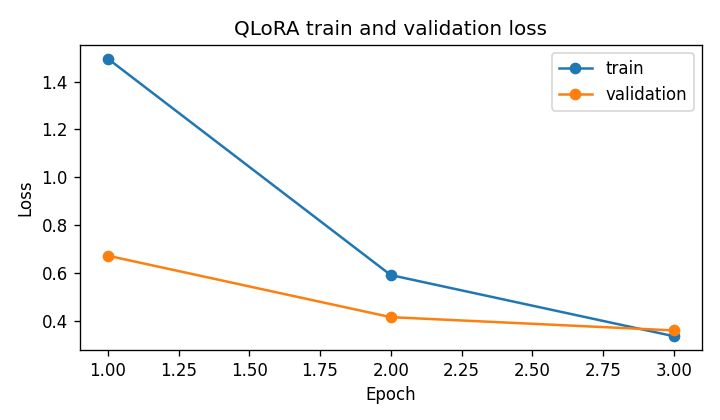

Validation loss fell from the first logged epoch to the last.
No OOM. Step 0 finished (max length 512, 7 target modules).


In [8]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# Train for 3 epochs. On CUDA OOM, retry the next smaller step and record which one ran.
import json
from pathlib import Path
from IPython.display import Image, display
from task2_genai.src import config
from task2_genai.src.qlora import load_student, make_trainer, resolve_max_length, save_loss_plot
from task2_genai.src.train_config import OOM_STEPS, losses_by_epoch, validation_loss_fell

loss_table = None
oom_log = "Training did not run in this session (no CUDA GPU)."
if not cuda_ready:
    print(oom_log)
else:
    import gc
    notes = []
    trainer = None
    # Raise 512 to 768 only when a training row does not fit. Later steps stay short.
    chosen_length, longest_tokens = resolve_max_length(tokenizer, OOM_STEPS[0]["max_seq_length"])
    print("Longest train row: %d tokens. Step 0 cap: %d." % (longest_tokens, chosen_length))
    for step in OOM_STEPS:
        # A later step rebuilds the adapter. The previous model is dropped first.
        if step["step"] != active_step:
            trainer = None
            del model
            gc.collect()
            torch.cuda.empty_cache()
            model, tokenizer = load_student(step["target_modules"])
            active_step = step["step"]
        length = chosen_length if step["step"] == 0 else step["max_seq_length"]
        adapter_dir = Path("/content/qlora-out") if IN_COLAB else config.OUTPUTS_DIR / "adapters"
        try:
            trainer = make_trainer(model, tokenizer, length, adapter_dir)
            trainer.train()
            # load_best_model_at_end has already restored the lowest eval loss.
            trainer.save_model(str(adapter_dir))
            if step["step"] == 0:
                notes.append(
                    "No OOM. Step 0 finished (max length %d, %d target modules)."
                    % (length, len(step["target_modules"]))
                )
            else:
                notes.append(
                    "Step %d finished after the earlier out-of-memory error (max length %d, %d target modules)."
                    % (step["step"], length, len(step["target_modules"]))
                )
            break
        except RuntimeError as exc:
            if "out of memory" not in str(exc).lower():
                raise
            trainer = None
            gc.collect()
            torch.cuda.empty_cache()
            notes.append("Step %d hit CUDA out of memory. %s" % (step["step"], exc))
            print(notes[-1])
    else:
        notes.append("All three OOM steps failed. See the messages above.")
    oom_log = " ".join(notes)
    if trainer is not None and getattr(trainer.state, "log_history", None):
        loss_table = losses_by_epoch(trainer.state.log_history)
        print("Epoch | train loss | val loss")
        for row in loss_table:
            print(row["epoch"], row["train_loss"], row["val_loss"])
        history_path = config.OUTPUTS_DIR / "loss_history.json"
        history_path.write_text(json.dumps(loss_table, indent=2), encoding="utf-8")
        plot_path = config.OUTPUTS_DIR / "loss_curve.png"
        save_loss_plot(loss_table, plot_path)
        display(Image(filename=str(plot_path)))
        if validation_loss_fell(loss_table):
            print("Validation loss fell from the first logged epoch to the last.")
        else:
            print("Validation loss did not fall from the first logged epoch to the last.")
    print(oom_log)


## 8. Merge Adapters and Push to Hugging Face Hub

The adapter is merged with `merge_and_unload()` onto a fresh float16 copy of the base model. The 4-bit training model is not merged. `HF_TOKEN` comes from Colab Secrets and is not printed.

In [11]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# Merge the best adapter into a fresh float16 base model and push that model.
# The 4-bit training copy is not the model that gets merged.
import os
from pathlib import Path
from task2_genai.src.client import load_api_keys
from task2_genai.src.qlora import merge_and_push
from task2_genai.src.train_config import ENV_HF_TOKEN, HF_REPO_ID

if not cuda_ready or adapter_dir is None or loss_table is None:
    print("Skipped: merge runs after a finished CUDA training run.")
else:
    # Colab Secrets, or a local .env. The token is not printed.
    if IN_COLAB:
        from google.colab import userdata
        os.environ[ENV_HF_TOKEN] = userdata.get(ENV_HF_TOKEN)
    else:
        load_api_keys()
    token = os.environ.get(ENV_HF_TOKEN, "").strip()
    if not token:
        print("Skipped: HF_TOKEN is not set. Add it in Colab Secrets and rerun this cell.")
    else:
        save_dir = Path("/content/northwind-merged") if IN_COLAB else Path("/tmp/northwind-merged")
        url = merge_and_push(adapter_dir, save_dir, token)
        print("Public model:", url)
        print("Hub repo id:", HF_REPO_ID)


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Public model: https://huggingface.co/GimsaraK/northwind-compliance-qwen2.5-1.5b
Hub repo id: GimsaraK/northwind-compliance-qwen2.5-1.5b


## 9. Out-of-Memory Debugging Log

If the T4 runs out of memory, section 7 retries in this order and records which step finished:

1. Max length 512, LoRA on attention and MLP (the intended run).
2. Max length 384, same modules.
3. Max length 384, attention projections only (`q_proj`, `k_proj`, `v_proj`, `o_proj`).

A run that does not hit an out-of-memory error says so. No failure is invented.


In [12]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2B QLoRA plan', Date: 2026-10-08 (see CITATIONS.md Entry 10)

# The training cell writes oom_log. This cell repeats it next to the planned order.
from task2_genai.src.train_config import OOM_STEPS

print("Planned fallback order:")
for step in OOM_STEPS:
    print(
        "  step %d: max length %d, modules %s"
        % (step["step"], step["max_seq_length"], ", ".join(step["target_modules"]))
    )
print()
print(oom_log if "oom_log" in dir() else "Training cell has not run yet.")


Planned fallback order:
  step 0: max length 512, modules q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
  step 1: max length 384, modules q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj
  step 2: max length 384, modules q_proj, k_proj, v_proj, o_proj

No OOM. Step 0 finished (max length 512, 7 target modules).


# Part 2C - Evaluation and Baseline Comparison

## 10. ROUGE-L: Base vs Fine-Tuned

Both models answer the same 20 held-out rows from `test.jsonl`, using the system and user turns stored in each row (the same system prompt the training rows use). The base model gets that system prompt and no fine-tuning. Both run in float16 with plain greedy decoding. The fine-tuned model is loaded from the public Hub repo, which also checks the published link, or from the merged folder of section 8 if the push did not happen. Answers are saved to `outputs/eval_predictions.jsonl`, so the metric and review cells can be re-run without a GPU.

ROUGE-L is computed on the whole answer in canonical form (compact JSON with sorted keys, the form the gold answers use), so key order and whitespace do not cost points. It is also computed on the `required_action` and `rationale` fields alone. The domain checks need no model: strict JSON validity, exact `policy_ids`, ids that are not in the manual, and `["NONE"]` on the rows the manual does not cover.


In [13]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# Generate base and fine-tuned answers on the test split. Without CUDA, reuse the saved file.
from task2_genai.src import config
from task2_genai.src import eval_config as ec
from task2_genai.src.eval_metrics import build_prediction_records, load_test_rows, read_predictions, write_predictions

try:
    import torch
    eval_cuda = torch.cuda.is_available()
except ImportError:
    eval_cuda = False

test_rows = load_test_rows()
predictions = []
if eval_cuda:
    from task2_genai.src.inference import free_gpu, resolve_finetuned_source, run_model

    # The 4-bit training model and the trainer from sections 5-8 are not needed any more.
    free_gpu(globals())
    outputs = {ec.BASE_KEY: run_model(config.STUDENT_MODEL, test_rows)}
    ft_source = resolve_finetuned_source()
    if ft_source is None:
        print("Fine-tuned model not found on the Hub or in %s. Only the base model was run." % ec.MERGED_LOCAL_DIR)
    else:
        outputs[ec.FINETUNED_KEY] = run_model(ft_source, test_rows)
    predictions = build_prediction_records(test_rows, outputs, ft_source)
    write_predictions(predictions)
elif ec.EVAL_PREDICTIONS_PATH.exists():
    predictions = read_predictions()
    print("No CUDA GPU. Loaded the saved answers from %s." % ec.EVAL_PREDICTIONS_PATH.name)
else:
    print("Skipped: generation needs a CUDA GPU and no saved answers exist yet. Run this notebook on a Colab T4.")

if predictions:
    print("Test rows:", len(test_rows))
    print("Fine-tuned source:", predictions[0]["ft_source"])
    for key in ec.MODEL_KEYS:
        print("%s answers: %d" % (ec.MODEL_LABELS[key], sum(1 for row in predictions if key in row)))
    sample = predictions[0]
    print("\n--- row 0 scenario ---\n" + sample["scenario"])
    print("--- expected ---\n" + sample["gold"])
    for key in ec.MODEL_KEYS:
        if key in sample:
            print("--- %s ---\n%s" % (ec.MODEL_LABELS[key], sample[key]))


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Test rows: 20
Fine-tuned source: GimsaraK/northwind-compliance-qwen2.5-1.5b
Base + system prompt answers: 20
Fine-tuned answers: 20

--- row 0 scenario ---
Ravi, a finance analyst, takes a brief fifteen-minute break and opens a personal budgeting spreadsheet he created years ago, using the pre-installed Microsoft Excel application on his corporate workstation. He does not install any new software, does not share his login credentials, saves the file to his local drive, and deletes it before returning to the quarterly financial close process.
--- expected ---
{"policy_ids":["NW-ACCEPT"],"rationale":"The policy permits a brief personal message of a few minutes on company systems.","required_action":"Record that the brief personal message is allowed."}
--- Base + system prompt ---
```json
{
  "policy_ids": ["NONE"],
  "required_action": "Ravi should not use personal applications on corporate workstations for non-work-related tasks.",
  "rationale": "The use of personal applications on cor

In [14]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# ROUGE-L and the domain checks for both models, as one comparison table.
import pandas as pd
from task2_genai.src.eval_metrics import comparison_rows, score_predictions, summarize, write_metrics
from task2_genai.src.manual import load_manual

eval_scores, eval_summary = None, None
have_both = bool(predictions) and all(key in predictions[0] for key in ec.MODEL_KEYS)
if not have_both:
    print("Skipped: needs base and fine-tuned answers from the cell above.")
else:
    manual_ids = {policy["id"] for policy in load_manual()["policies"]}
    eval_scores = score_predictions(predictions, manual_ids)
    eval_summary = summarize(eval_scores)
    write_metrics(eval_summary)
    keys = ["rouge_l", "rouge_l_action", "rouge_l_rationale", "json_valid_pct", "policy_exact_pct", "unknown_id_pct", "none_correct_pct"]
    columns = ["Metric (test set, n=%d)" % len(predictions), ec.MODEL_LABELS[ec.BASE_KEY], ec.MODEL_LABELS[ec.FINETUNED_KEY]]
    display(pd.DataFrame(comparison_rows(eval_summary, keys), columns=columns))


,"Metric (test set, n=20)",Base + system prompt,Fine-tuned
0,"ROUGE-L F1, whole answer (canonical JSON)",0.254,0.581
1,"ROUGE-L F1, required_action field",0.171,0.582
2,"ROUGE-L F1, rationale field",0.180,0.425
3,"Valid JSON, strict (%)",0,100
4,policy_ids exact match (%),20,80
5,Answers with an id not in the manual (%),0,5
6,"NONE on not-covered rows (%), n=4",100,75


## 11. Additional Metric (BERTScore F1 / LLM-as-Judge)

BERTScore F1 uses `roberta-large` on the same canonical answers as ROUGE-L.

The LLM judge is `google/gemma-4-31b-it:free` on OpenRouter. It is a different model from the Qwen student and from the gpt-oss teacher that wrote the reference answers, so the teacher does not grade against its own references. If Gemma fails on a row after one repair attempt, `nvidia/nemotron-3-super-120b-a12b:free` (also on OpenRouter) grades that row, and the grader is recorded per row. Neither judge is the teacher or the student. Gemma is listed as the Task 2A backup teacher, but it wrote none of the dataset (`fallback_calls` is 0 in `outputs/generation_report.json`).

The judge sees the full policy manual, the scenario, the reference answer, and one answer. It is not told which model wrote the answer. It returns four scores of 0-2 as JSON, validated with Pydantic: `policy_correct`, `action_faithful`, `rationale_grounded`, `no_invention`. The total out of 8 is added up here, not by the judge. The full judge prompt is in `prompts/judge_system.txt`.


In [15]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# BERTScore F1 for both models.
from task2_genai.src.eval_metrics import add_bertscore

if eval_scores is None:
    print("Skipped: needs the scores from section 10.")
else:
    add_bertscore(eval_scores, predictions)
    eval_summary = summarize(eval_scores)
    for key in ec.MODEL_KEYS:
        print("%-22s BERTScore F1 (%s): %.3f" % (ec.MODEL_LABELS[key], ec.BERTSCORE_MODEL, eval_summary[key]["bertscore_f1"]))


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-large
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Base + system prompt   BERTScore F1 (roberta-large): 0.885
Fine-tuned             BERTScore F1 (roberta-large): 0.941


In [16]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# LLM-as-judge with the four-criterion rubric. Keys come from Colab Secrets and are not printed.
import json
from task2_genai.src.client import build_judge_clients, load_api_keys
from task2_genai.src.generate import _read_jsonl
from task2_genai.src.judge import judge_all
from task2_genai.src.prompts import judge_system, write_judge_prompt

write_judge_prompt(ec.JUDGE_PROMPT_PATH)
print(judge_system().split("Policy manual:")[0].strip())
print("(The full policy manual follows in the prompt. See %s.)\n" % ec.JUDGE_PROMPT_PATH.name)

judge_rows = None
if eval_scores is None:
    print("Skipped: needs the scores from section 10.")
else:
    key_status = load_api_keys()
    # Both judges run on OpenRouter.
    print("OPENROUTER_API_KEY set:", key_status[config.ENV_OPENROUTER_API_KEY])
    judge_clients = build_judge_clients()
    if judge_clients:
        judge_rows = judge_all(predictions, judge_clients)
    elif ec.JUDGE_SCORES_PATH.exists():
        judge_rows = _read_jsonl(ec.JUDGE_SCORES_PATH)
        print("No judge key set. Loaded the saved verdicts from %s." % ec.JUDGE_SCORES_PATH.name)
    else:
        print("Skipped: OPENROUTER_API_KEY is not set and no saved verdicts exist.")
if judge_rows is not None:
    eval_summary = summarize(eval_scores, judge_rows)
    keys = ["judge_total", "judge_policy_correct", "judge_action_faithful", "judge_rationale_grounded", "judge_no_invention", "judged"]
    columns = ["Judge metric (test set, n=%d)" % len(predictions), ec.MODEL_LABELS[ec.BASE_KEY], ec.MODEL_LABELS[ec.FINETUNED_KEY]]
    display(pd.DataFrame(comparison_rows(eval_summary, keys), columns=columns))
    for key in ec.MODEL_KEYS:
        print("%s graders: %s" % (ec.MODEL_LABELS[key], eval_summary[key]["judge_graders"]))
    unjudged = [row for row in judge_rows if row["status"] != "judged"]
    print("Unjudged answers: %d" % len(unjudged))
    for row in unjudged:
        print("  row %d (%s): %s" % (row["id"], row["model"], row["error"]))
    example = next((row for row in judge_rows if row["status"] == "judged" and row["model"] == ec.FINETUNED_KEY), None)
    if example:
        print("\nExample verdict, row %d, fine-tuned, graded by %s:" % (example["id"], example["grader"]))
        print(json.dumps(example["scores"], indent=2))


You grade answers from a compliance assistant for Northwind Components, a fictional company.
Grade only against the policy manual below. The reference answer was written from the same manual but can contain mistakes. When the reference and the manual disagree, the manual wins.

Score each criterion 0, 1, or 2:
- policy_correct: 2 = the policy_ids are exactly the ones the manual applies to this scenario (["NONE"] when no rule covers it). 1 = partly right, for example one of two ids, or a correct id plus a wrong one. 0 = wrong, missing, or not in the manual.
- action_faithful: 2 = the required_action is what the applicable clause requires. 1 = in the right direction but incomplete or partly wrong. 0 = contradicts the clause, or no action is given.
- rationale_grounded: 2 = the rationale states the actual rule from the manual. 1 = vague or partly accurate. 0 = cites a rule that does not exist or does not apply.
- no_invention: 2 = no invented rule, limit, deadline, amount, or policy id. 1

,"Judge metric (test set, n=20)",Base + system prompt,Fine-tuned
0,"LLM judge total, mean of 8",2.15,5.20
1,"Judge: policy_correct, mean of 2",0.30,1.50
2,"Judge: action_faithful, mean of 2",0.35,1.20
3,"Judge: rationale_grounded, mean of 2",0.70,1.20
4,"Judge: no_invention, mean of 2",0.80,1.30
5,Judge: rows graded,20 of 20,20 of 20


Base + system prompt graders: {'openrouter:nvidia/nemotron-3-super-120b-a12b:free': 20}
Fine-tuned graders: {'openrouter:nvidia/nemotron-3-super-120b-a12b:free': 20}
Unjudged answers: 0

Example verdict, row 0, fine-tuned, graded by openrouter:nvidia/nemotron-3-super-120b-a12b:free:
{
  "policy_correct": {
    "score": 2,
    "reason": "NW-ACCEPT is the only policy that governs personal use of company systems in this scenario."
  },
  "action_faithful": {
    "score": 1,
    "reason": "The answer correctly says to stop and end the session but incorrectly adds reporting to IT instead of referring to the manager as required."
  },
  "rationale_grounded": {
    "score": 0,
    "reason": "The rationale claims a rule about brief, unobtrusive, business-hours-limited personal use, which is not stated in NW-ACCEPT."
  },
  "no_invention": {
    "score": 0,
    "reason": "The answer invents requirements (unobtrusive, business-hours limit, reporting to IT) not found in the manual."
  }
}


,"Metric (test set, n=20)",Base + system prompt,Fine-tuned
0,"ROUGE-L F1, whole answer (canonical JSON)",0.254,0.581
1,"ROUGE-L F1, required_action field",0.171,0.582
2,"ROUGE-L F1, rationale field",0.180,0.425
3,BERTScore F1 (roberta-large),0.885,0.941
4,"LLM judge total, mean of 8",2.15,5.20
5,"Judge: policy_correct, mean of 2",0.30,1.50
6,"Judge: action_faithful, mean of 2",0.35,1.20
7,"Judge: rationale_grounded, mean of 2",0.70,1.20
8,"Judge: no_invention, mean of 2",0.80,1.30
9,Judge: rows graded,20 of 20,20 of 20


ROUGE-L: base 0.254, fine-tuned 0.581, difference +0.327
BERTScore F1: base 0.885, fine-tuned 0.941, difference +0.056
Judge total: base 2.150, fine-tuned 5.200, difference +3.050


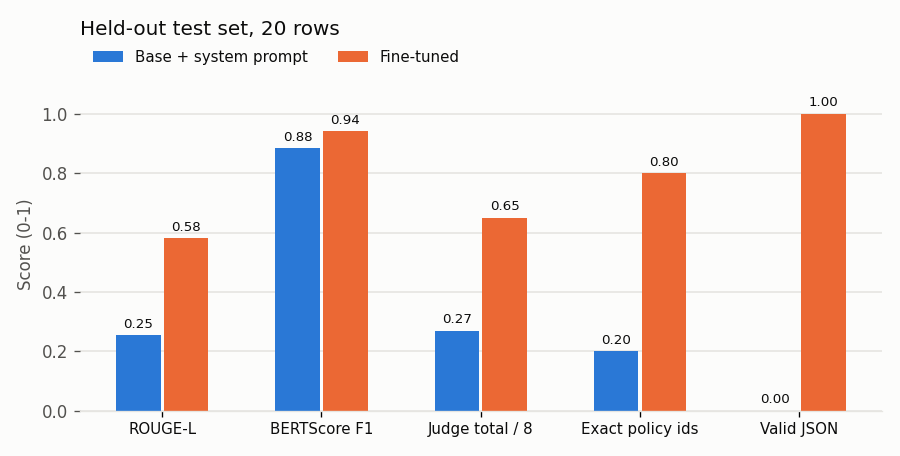

In [17]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# Full base vs fine-tuned comparison, saved to outputs/eval_metrics.json and outputs/eval_comparison.png.
import json
from IPython.display import Image
from task2_genai.src.eval_metrics import save_comparison_chart

if eval_summary is None:
    print("Skipped: needs the scores from section 10.")
else:
    write_metrics(eval_summary)
    columns = ["Metric (test set, n=%d)" % len(predictions), ec.MODEL_LABELS[ec.BASE_KEY], ec.MODEL_LABELS[ec.FINETUNED_KEY]]
    display(pd.DataFrame(comparison_rows(eval_summary), columns=columns))
    for key, name in (("rouge_l", "ROUGE-L"), ("bertscore_f1", "BERTScore F1"), ("judge_total", "Judge total")):
        base_value = eval_summary[ec.BASE_KEY].get(key)
        ft_value = eval_summary[ec.FINETUNED_KEY].get(key)
        if base_value is not None and ft_value is not None:
            print("%s: base %.3f, fine-tuned %.3f, difference %+.3f" % (name, base_value, ft_value, ft_value - base_value))
    save_comparison_chart(eval_summary)
    if ec.EVAL_CHART_PATH.exists():
        display(Image(filename=str(ec.EVAL_CHART_PATH)))


## 12. Manual Review and Hallucination Rate

All 20 fine-tuned answers are reviewed by hand (the spec minimum is 10). Each answer is checked against the policy manual, not only against the expected answer. The expected answers were written by the teacher model and can be wrong.

| Label | Rule |
|---|---|
| correct | The `policy_ids` are the right ones for the scenario under the manual, and the required action is one the clause allows. Wording may differ from the expected answer. |
| partially_correct | A real, relevant policy is named, but the action is incomplete or slightly off, or one of two required ids is missing. Nothing is invented. |
| hallucinated | An id that is not in the manual; an invented rule, limit, or deadline; a wrong policy stated as applying; `NONE` when a policy does apply; a policy cited for a case the manual does not cover; or no usable JSON answer. |

The first cell writes `outputs/manual_review.json` with a suggested label from the domain checks and the judge. The reviewer sets `label` and `note` on every row. A suggestion is only a starting point, and the table marks every row where the reviewer overrode it. Hallucination rate = hallucinated / reviewed.


In [18]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

# Write the review file with suggested labels. It never overwrites a file that already has human labels.
from collections import Counter
from task2_genai.src.eval_metrics import build_review_rows, write_review

if eval_scores is None:
    print("Skipped: needs the scores from section 10.")
else:
    review_rows = build_review_rows(predictions, eval_scores, judge_rows)
    if write_review(review_rows):
        print("Wrote %d rows to %s. Every label is empty until the manual review." % (len(review_rows), ec.MANUAL_REVIEW_PATH.name))
    else:
        print("%s already has human labels. It was not overwritten." % ec.MANUAL_REVIEW_PATH.name)
    print("Suggested labels:", dict(Counter(row["suggested_label"] for row in review_rows)))


Wrote 20 rows to manual_review.json. Every label is empty until the manual review.
Suggested labels: {'hallucinated': 6, 'correct': 7, 'partially_correct': 7}


In [1]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

import sys
from pathlib import Path

# This cell is run locally after the manual review, without re-running the setup cell.
_here = Path.cwd().resolve()
for _root in (_here, *_here.parents, Path("/content/CDAZZDEV-MLE-Gimsara_Elgiriyage")):
    if (_root / "task2_genai" / "src").exists():
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Labelled review table and hallucination rate, from the reviewer's labels only.
import pandas as pd
from task2_genai.src import eval_config as ec
from task2_genai.src.eval_metrics import hallucination_rate, read_review

review = read_review()
if review is None:
    print("Review pending: %s has not been written yet." % ec.MANUAL_REVIEW_PATH.name)
else:
    rows = review["rows"]
    table = pd.DataFrame(
        [
            {
                "id": row["id"],
                "situation": row["situation"],
                "scenario": row["scenario"][: ec.REVIEW_SCENARIO_CHARS] + ("..." if len(row["scenario"]) > ec.REVIEW_SCENARIO_CHARS else ""),
                "expected": row["expected"],
                "output": row["output"],
                "suggested": row["suggested_label"],
                "label": row["label"] or "(pending)",
                "overrode": bool(row["label"]) and row["label"] != row["suggested_label"],
                "note": row["note"],
            }
            for row in rows
        ]
    )
    with pd.option_context("display.max_colwidth", 400):
        display(table)
    result = hallucination_rate(rows)
    if result["status"] == "pending":
        print("Review pending: %d of %d rows labelled. The rate needs at least %d." % (result["labelled"], result["total"], ec.MIN_REVIEWED))
    else:
        print("Reviewed: %d of %d fine-tuned answers" % (result["labelled"], result["total"]))
        for label in ec.LABELS:
            print("  %-18s %d" % (label, result["counts"][label]))
        print("Overrode the suggestion on %d rows" % int(table["overrode"].sum()))
        print("Hallucination rate: %d / %d = %.1f%%" % (result["counts"][ec.LABEL_HALLUCINATED], result["labelled"], result["rate_pct"]))


,id,situation,scenario,expected,output,suggested,label,overrode,note
0,0,compliant,"Ravi, a finance analyst, takes a brief fifteen-minute break and opens a personal budgeting spreadsheet he created years ago, using the pre-installed Microsoft E...","{""policy_ids"":[""NW-ACCEPT""],""rationale"":""The policy permits a brief personal message of a few minutes on company systems."",""required_action"":""Record that the brief personal message is allowed.""}","{""policy_ids"":[""NW-ACCEPT""],""rationale"":""The rule states that personal use of company systems must be brief, unobtrusive, and limited to business hours."",""required_action"":""Tell Ravi to stop, end the session, and report it to IT.""}",hallucinated,hallucinated,False,"Right policy, but the rationale invents 'unobtrusive' and 'business hours' limits, and the action (stop, report to IT) is not in NW-ACCEPT. Brief personal use in a break is not one of the banned uses, so it should be recorded as allowed. The expected answer calls the spreadsheet a 'message' but reaches the allowed outcome."
1,1,compliant,"Diego Martinez, a mechanical engineer, filed an expense for $300 travel to a client site, including airfare and hotel. He attached the itemized receipt, secured...","{""policy_ids"":[""NW-EXPENSE""],""rationale"":""The claim has an itemized receipt, prior manager approval, is for a business expense, and was filed within 30 days, satisfying the NW-EXPENSE rule."",""required_action"":""Approve the claim and record that it includes an itemized receipt, manager approval, and is within the allowed category and timeframe.""}","{""policy_ids"":[""NW-EXPENSE""],""rationale"":""The claim includes an itemized receipt, prior manager approval, and is within the 30-day limit, which are all required by NW-EXPENSE."",""required_action"":""Approve the claim and record that it includes an itemized receipt, prior manager approval, and is within the 30-day limit.""}",correct,correct,False,"Right policy, approves a claim with receipt, prior approval, allowed category and 30-day filing, as NW-EXPENSE requires."
2,2,clear_breach,"Jordan, a sales representative at the New York office, was offered a $150 catered dinner by SupplierCo while the company was evaluating bids for a new component...","{""policy_ids"":[""NW-GIFT""],""rationale"":""The gift exceeds the $25 limit and was given during an open bid, which the NW-GIFT policy prohibits, so it must be refused or handed to Compliance."",""required_action"":""Refuse the gift, hand it to Compliance, and record the required disclosure.""}","{""policy_ids"":[""NW-ACCEPT""],""rationale"":""The policy states that company business must not be conducted during an open bid, and a gift above $25 is prohibited."",""required_action"":""Reject the dinner and refer Jordan to their manager.""}",hallucinated,hallucinated,False,"Cites NW-ACCEPT for a supplier dinner during an open bid. NW-GIFT applies, and the 'no business during an open bid' rule is invented. Refusing the dinner is the right direction, but it refers to the manager instead of Compliance and records no disclosure."
3,3,compliant,"Li, a procurement analyst at the Seattle office, submitted a leave application on September 2 for a five-day vacation beginning September 12. Her submission was...","{""policy_ids"":[""NW-LEAVE""],""rationale"":""Rule requires a 5-day notice and no leave during a freeze week; both conditions are met."",""required_action"":""Approve it and record the dates.""}","{""policy_ids"":[""NW-LEAVE""],""rationale"":""The request meets the five-day notice and no freeze week requirement."",""required_action"":""Approve the leave and record the date.""}",correct,correct,False,"Right policy and outcome: 5-day notice met, no freeze week, so approve and record the dates."
4,4,compliant,"Lena, a support engineer at the Austin data center, accessed a client's email and account ID in the ticketing system to diagnose a reported outage. The informat...","{""policy_ids"":[""NW-PRIVACY""],""

Reviewed: 20 of 20 fine-tuned answers
  correct            7
  partially_correct  4
  hallucinated       9
Overrode the suggestion on 5 rows
Hallucination rate: 9 / 20 = 45.0%


## 13. Qualitative Analysis

In [2]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2C evaluation plan' (see CITATIONS.md Entry 12)

import sys
from pathlib import Path

# This cell is run locally after the manual review, without re-running the setup cell.
_here = Path.cwd().resolve()
for _root in (_here, *_here.parents, Path("/content/CDAZZDEV-MLE-Gimsara_Elgiriyage")):
    if (_root / "task2_genai" / "src").exists():
        break
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# The rows the two paragraphs below cite, base and fine-tuned side by side.
from task2_genai.src import eval_config as ec
from task2_genai.src.eval_metrics import read_predictions, read_review

# Every row cited in the two paragraphs below.
QUALITATIVE_ROW_IDS = [1, 14, 12, 10, 2, 19, 17, 13, 4, 16, 0, 6, 7]

predictions_by_id = {row["id"]: row for row in read_predictions()}
labels_by_id = {row["id"]: row for row in (read_review() or {}).get("rows", [])}
if not QUALITATIVE_ROW_IDS or not predictions_by_id:
    print("Evidence rows are chosen after the Colab run.")
for row_id in QUALITATIVE_ROW_IDS:
    row = predictions_by_id[row_id]
    review_row = labels_by_id.get(row_id, {})
    print("=" * 100)
    print("Row %d | %s | %s | reviewer label: %s" % (row_id, row["topic"], row["situation"], review_row.get("label") or "(pending)"))
    print("Scenario: " + row["scenario"])
    print("Expected: " + row["gold"])
    print("Base:     " + row[ec.BASE_KEY])
    print("Tuned:    " + row[ec.FINETUNED_KEY])
    if review_row.get("note"):
        print("Note:     " + review_row["note"])


Row 1 | expenses | compliant | reviewer label: correct
Scenario: Diego Martinez, a mechanical engineer, filed an expense for $300 travel to a client site, including airfare and hotel. He attached the itemized receipt, secured prior approval from his manager Priya Singh, and submitted the claim 20 days after returning. The travel is for business purposes, not personal, and the claim is within the 30-day limit, so it complies with policy.
Expected: {"policy_ids":["NW-EXPENSE"],"rationale":"The claim has an itemized receipt, prior manager approval, is for a business expense, and was filed within 30 days, satisfying the NW-EXPENSE rule.","required_action":"Approve the claim and record that it includes an itemized receipt, manager approval, and is within the allowed category and timeframe."}
Base:     ```json
{
  "policy_ids": ["NONE"],
  "required_action": "No action is required as the expense complies with all Northwind Components policies.",
  "rationale": "The expense meets all the crit

**Where fine-tuning improved the model.** Fine-tuning taught the model a policy manual it never sees at inference time. Without it, the base model answered `["NONE"]` on all 20 test rows, wrapped every answer in a markdown fence (0% strict JSON), and filled the gap with generic rules it made up. On row 14 it cites a "data usage policy" that needs manager approval, and on row 1 it says no policy applies to a travel claim. The fine-tuned model returns bare JSON on 20 of 20 rows and names the exact policy ids on 16 of 20 (80% vs 20%; the base model's 20% is only the four not-covered rows). Row 1 now cites NW-EXPENSE and approves the claim on its receipt, prior approval, and 30-day conditions. Row 14 cites NW-PRIVACY and gives the clause's three actions (stop the copy, delete it, file a Privacy report) with the real 4-hour window. Row 12, a two-policy case, gets both NW-GIFT and NW-EXPENSE. On questions the manual does not cover, it learned the expected referral: row 10 returns `["NONE"]` and sends the employee to the compliance officer, where the base model invented an "IT Governance Committee". Every metric moves the same way: ROUGE-L 0.254 to 0.581, BERTScore F1 0.885 to 0.941, and the judge total 2.15 to 5.20 out of 8, with `policy_correct` rising from 0.30 to 1.50 out of 2.

**Remaining failure modes and what would fix them.** The manual review labelled 9 of the 20 fine-tuned answers hallucinated (45%), 4 partially correct, and 7 correct. Three patterns explain most of the errors. First, look-alike clauses get confused: gift cases go to NW-ACCEPT on rows 2 and 19, a not-covered pricing question is answered with NW-PRIVACY on row 17, and row 13 invents an id, NW-LOCKOUT, from the word "lockout". Second, the policy is right but the outcome is wrong: row 4 treats permitted data use as a breach, and row 16 rejects a valid leave request because of an unrelated privacy breach, so one clause's action leaks into another (row 0 does the same with a stop-and-report action). Third, the rationale adds invented specifics even when the id and action are right: a 4-working-day deadline on row 6 and a supervisor-approval exception on row 7. With 160 training rows, each policy appears about 20 times and each topic and situation pair only about 4 times, which is too little to separate neighbouring clauses. The next step is more targeted data: contrastive pairs that differ in one fact (a gift just above or below 25 USD, an open bid or none), more compliant and two-policy rows where one policy is met and the other is breached, and not-covered rows written to look like a real policy. A second-model check of every label against the manual would also remove noisy references such as row 0, whose expected answer calls a spreadsheet a "message". On the training side, targets whose rationale quotes the clause text word for word would teach the model to copy rules rather than paraphrase them, which is where the invented deadlines come from. More epochs are not the fix: validation loss was already flattening (0.417 to 0.361) while train loss kept falling.


# Appendix

## A. Teacher-Model System Prompt (full text)

In [21]:
# AI-ASSISTED: Cursor Agent (claude-sonnet-5.5), Prompt: 'Implement the Task 2A dataset plan', Date: 2026-10-08 (see CITATIONS.md Entry 8)

# Full teacher system prompt, including the policy manual. This is the text sent as the system turn.
from task2_genai.src import config
print(config.TEACHER_PROMPT_PATH.read_text(encoding="utf-8"))


You write training rows for a compliance assistant at Northwind Components, a fictional company.
Use only the policy manual below. Do not invent policies, dollar limits, deadlines, or actions that the manual does not state.

Return a JSON object with one key, "examples". Its value is an array of exactly 5 objects.
Each object has these keys and no others:
- scenario: the employee situation, in the word range given in the user message. Name a role and concrete facts. Do not mention a policy id in the scenario.
- policy_ids: array of policy ids, following the user message.
- required_action: the action that clause requires, in one or two sentences, using only the manual's required action.
- rationale: one or two sentences that cite the rule. Do not add a new rule.
- topic: copy the topic string from the user message.
- situation: copy the situation string from the user message.

The 5 scenarios must differ in role, workplace, and facts. Do not reuse the same person names or the same numb

## Citations

See [`CITATIONS.md`](../CITATIONS.md) in the repository root. AI-assisted cells are also cited inline.